In [1]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from numpy.fft import fft, fftfreq, fftshift

In [ ]:
#neural network design
class PINN(nn.Module):
    def __init__(self):
        super(PINN,self).__init__()
        self.hidden=nn.Sequential(
            nn.Linear(2,50),
            nn.Tanh(),
            nn.Linear(50,50),
            nn.Tanh(),
            nn.Linear(50,50),
            nn.Tanh(),
            nn.Linear(50,50),
            nn.Tanh(),
            nn.Linear(50,1)
        )

    def forward(self,x,t):
        inputs=torch.cat([x,t],dim=1)
        u=self.hidden(inputs)
        return u


In [ ]:

def pde_residual(x,t,model,nu=0.01):
    x.requires_grad=True
    t.requires_grad=True

    u=model(x,t)
    u_t=torch.autograd.grad(u,t,torch.ones_like(u),create_graph=True)[0]
    u_x=torch.autograd.grad(u,x,torch.ones_like(u),create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,torch.ones_like(u_x),create_graph=True)[0]

    residual=u_t + u*u_x - nu/(np.pi)*u_xx
    return residual

def initial_condition(x):
    return -torch.sin(np.pi*x)


def boundary_condition(x,t):
    return torch.zeros_like(t)


In [ ]:
#generating training data set
x=torch.linspace(-1,1,200).view(-1,1)
t=torch.linspace(0,1,100).view(-1,1)
x_train,t_train=torch.meshgrid(x.squeeze(),t.squeeze(),indexing='xy')
x_train=x_train.reshape(-1,1)
t_train=t_train.reshape(-1,1)

In [ ]:
model=PINN()
optimizer=optim.Adam(model.parameters(),lr=0.005)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable Parameters: {trainable_params:,}")

Trainable Parameters: 7,851


In [ ]:
#training the neural network
num_epochs=12000
l=[]
for epoch in range(num_epochs):
    model.train()

    u_pred=model(x,torch.zeros_like(x))
    u_true=initial_condition(x)
    loss_ic=torch.mean((u_pred - u_true)**2)

    u_pred_left=model(torch.full_like(t,-1),t)
    u_pred_right=model(torch.full_like(t,1),t)
    loss_bc=torch.mean((u_pred_left-boundary_condition(torch.full_like(t,-1),t))**2) + \
            torch.mean((u_pred_right-boundary_condition(torch.full_like(t,1),t))**2)
    
    residual=pde_residual(x_train,t_train,model)
    loss_pde=torch.mean(residual**2)

    loss=loss_ic + loss_bc + loss_pde

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    l.append(loss.item())

    if (epoch)%500==0:
        print(f'Epoch[{epoch+1}/{num_epochs}],loss:{loss.item():.4f}')

Epoch[1/12000],loss:0.4861
Epoch[501/12000],loss:0.1203
Epoch[1001/12000],loss:0.0976
Epoch[1501/12000],loss:0.0959
Epoch[2001/12000],loss:0.0852
Epoch[2501/12000],loss:0.0822
Epoch[3001/12000],loss:0.0811
Epoch[3501/12000],loss:0.0775
Epoch[4001/12000],loss:0.0754
Epoch[4501/12000],loss:0.0726
Epoch[5001/12000],loss:0.0665
Epoch[5501/12000],loss:0.0554
Epoch[6001/12000],loss:0.0225
Epoch[6501/12000],loss:0.0078
Epoch[7001/12000],loss:0.0044
Epoch[7501/12000],loss:0.0028
Epoch[8001/12000],loss:0.0023
Epoch[8501/12000],loss:0.0015
Epoch[9001/12000],loss:0.0011
Epoch[9501/12000],loss:0.0009
Epoch[10001/12000],loss:0.0009
Epoch[10501/12000],loss:0.0012
Epoch[11001/12000],loss:0.0008
Epoch[11501/12000],loss:0.0015


0.001485216780565679

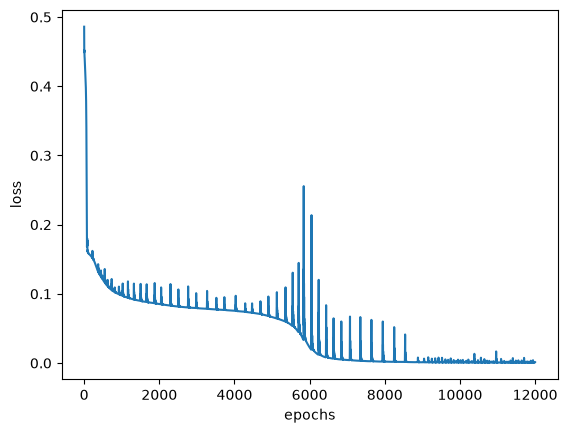

In [7]:
plt.xlabel("epochs")
plt.ylabel("loss")
plt.plot(l)
l[11999]

In [8]:


data = np.load("Burgers.npz")
t_ref = data["t"].flatten()       
x_ref = data["x"].flatten()       
exact = data["usol"].T           


t_grid, x_grid = torch.meshgrid(
    torch.tensor(t_ref, dtype=torch.float32), 
    torch.tensor(x_ref, dtype=torch.float32), 
    indexing='ij'
)

t_test = t_grid.reshape(-1, 1)
x_test = x_grid.reshape(-1, 1)

model.eval()
with torch.no_grad():
    u_pred_flat = model(x_test, t_test).numpy()

u_pred = u_pred_flat.reshape(100, 256)
L2_error = np.linalg.norm(exact - u_pred) / np.linalg.norm(exact)
print(f"Relative L2 Error: {L2_error:.4e}")

Relative L2 Error: 1.0096e-01


(100, 1) (256, 1) (100, 256)


Text(0.5, 1.0, 'reference solution of burgers equation')

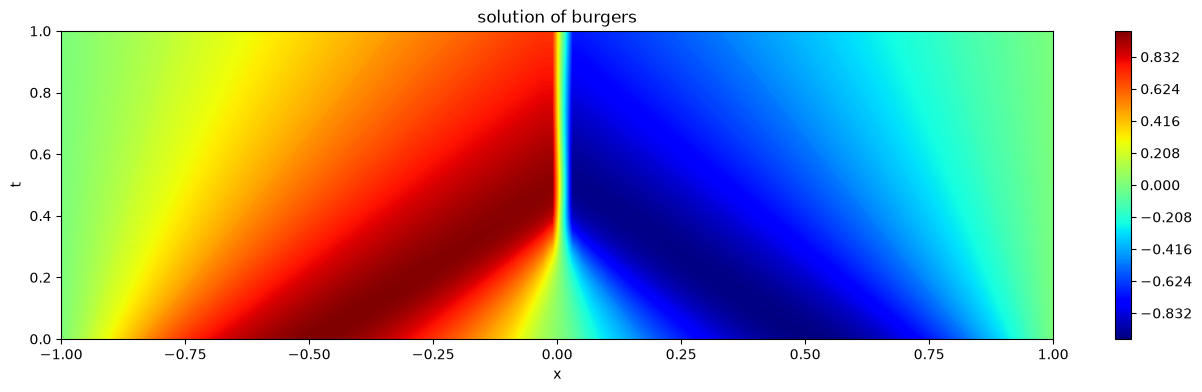

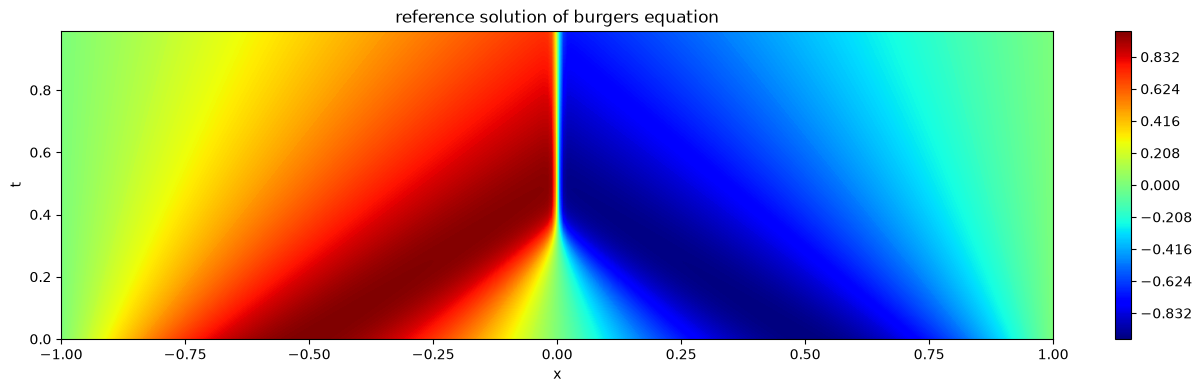

In [9]:
data=np.load("Burgers.npz")
t_ref,x_ref,exact=data["t"],data["x"],data["usol"].T
print(t_ref.shape,x_ref.shape,exact.shape)
x_ref,t_ref=np.meshgrid(x_ref,t_ref)


x_test=torch.linspace(-1,1,100).view(-1,1)
t_test=torch.linspace(0,1,100).view(-1,1)
x_test,t_test=torch.meshgrid(x_test.squeeze(),t_test.squeeze(),indexing='xy')
x_test=x_test.reshape(-1,1)
t_test=t_test.reshape(-1,1)

model.eval()
with torch.no_grad():
    u_pred=model(x_test,t_test).numpy()

x_test=x_test.numpy().reshape(100,100)
t_test=t_test.numpy().reshape(100,100)
u_pred=u_pred.reshape(100,100)

plt.figure(figsize=(16,4))
plt.contourf(x_test,t_test,u_pred,levels=250,cmap='jet')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('t')
plt.title('solution of burgers')


plt.figure(figsize=(16,4))
plt.contourf(x_ref,t_ref,exact,levels=250,cmap='jet')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('t')
plt.title('reference solution of burgers equation')

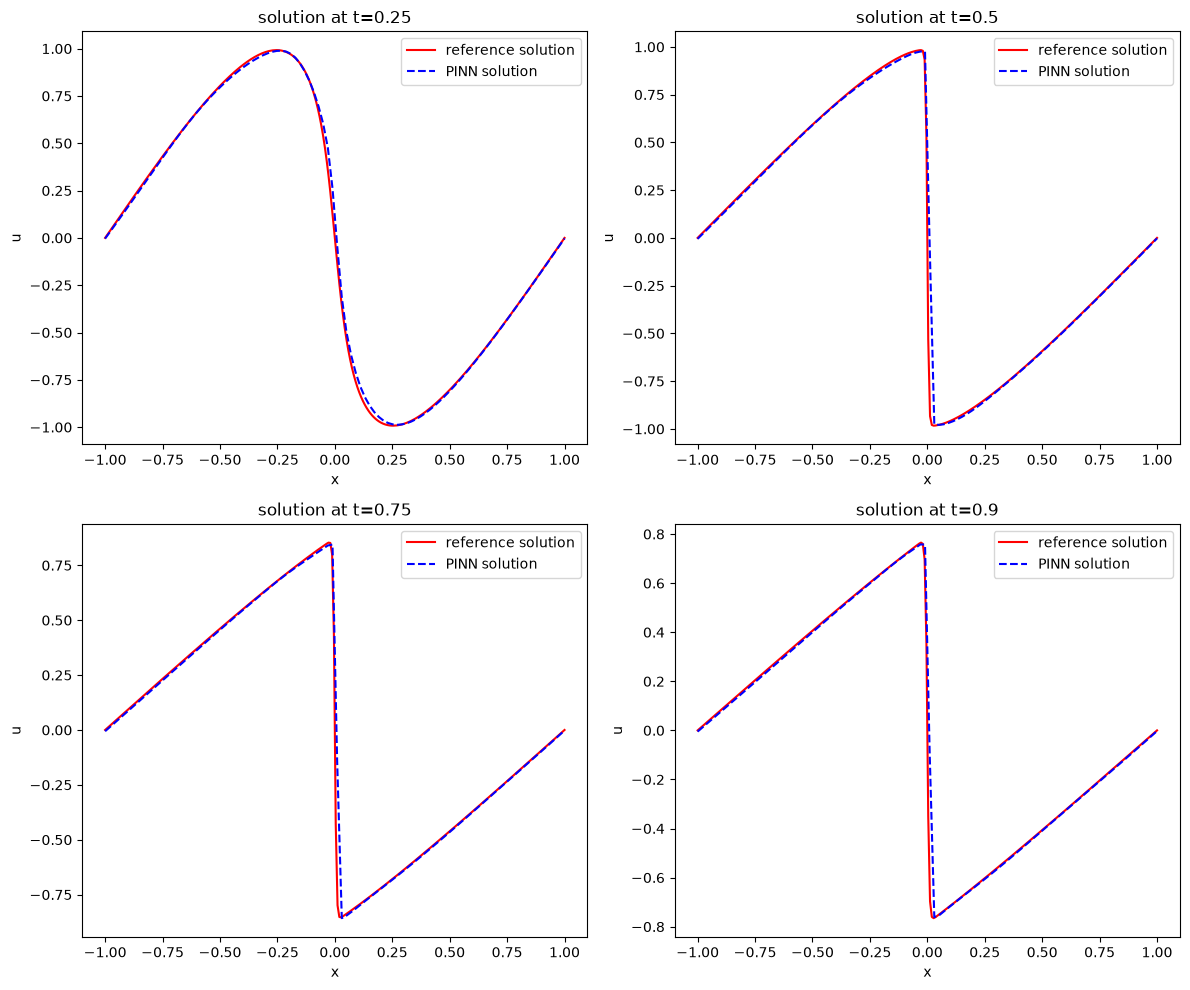

In [10]:
time_slices=[0.25,0.5,0.75,0.9]

num_plots=len(time_slices)
cols=2
rows=(num_plots//cols)+(num_plots%cols)

fig,axs=plt.subplots(rows,cols,figsize=(12,5*rows))
axs=axs.flatten()

for i,t_val in enumerate(time_slices):
    idx_ref=np.argmin(np.abs(t_ref[:,0]-t_val))
    u_ref_slice=exact[idx_ref,:]

    t_slice=t_val*np.ones((100,1))
    x_slice=np.linspace(-1,1,100).reshape(-1,1)

    model.eval()
    with torch.no_grad():
        u_pinn_slice=model(torch.tensor(x_slice,dtype=torch.float32), torch.tensor(t_slice,dtype=torch.float32)).numpy()


    axs[i].plot(x_ref[0,:],u_ref_slice,'r-',label='reference solution')
    axs[i].plot(x_slice,u_pinn_slice,'b--',label='PINN solution')
    axs[i].set_xlabel('x')
    axs[i].set_ylabel('u')
    axs[i].set_title(f'solution at t={t_val}')
    axs[i].legend()

for j in range(num_plots,len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()


    

Prediction shape: (256, 100)  (Nx, Nt)
x range: [-1.00, 1.00]


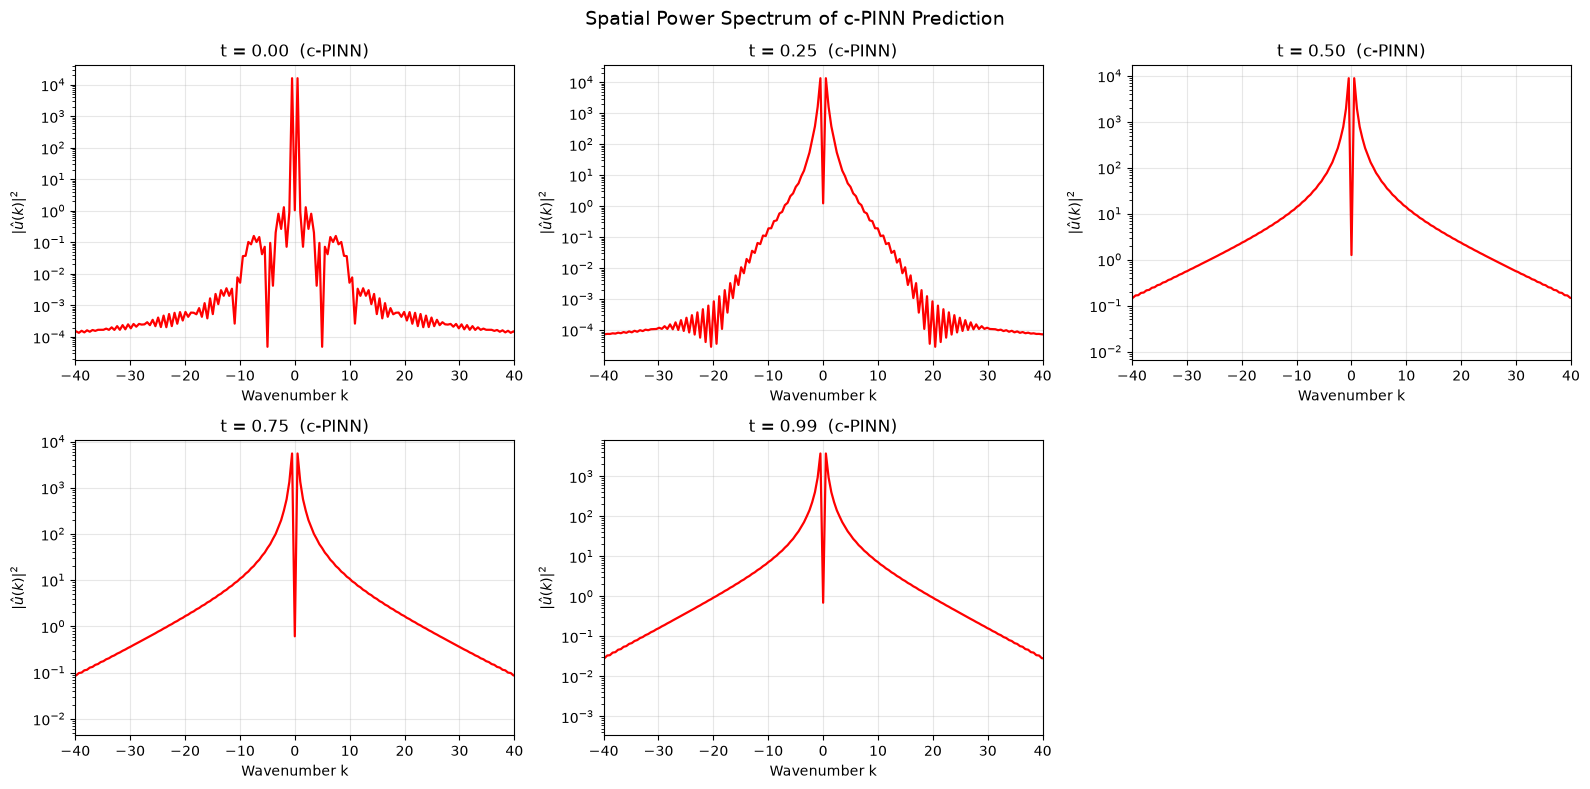


=== High-frequency content of c-PINN prediction ===
t = 0.00:  |k|>10 → 0.0000   |k|>20 → 0.0000
t = 0.25:  |k|>10 → 0.0000   |k|>20 → 0.0000
t = 0.50:  |k|>10 → 0.0112   |k|>20 → 0.0024
t = 0.75:  |k|>10 → 0.0126   |k|>20 → 0.0025
t = 0.99:  |k|>10 → 0.0110   |k|>20 → 0.0017
Reference shape: (256, 100) (Nx, Nt)
x range: [-1.00, 1.00]


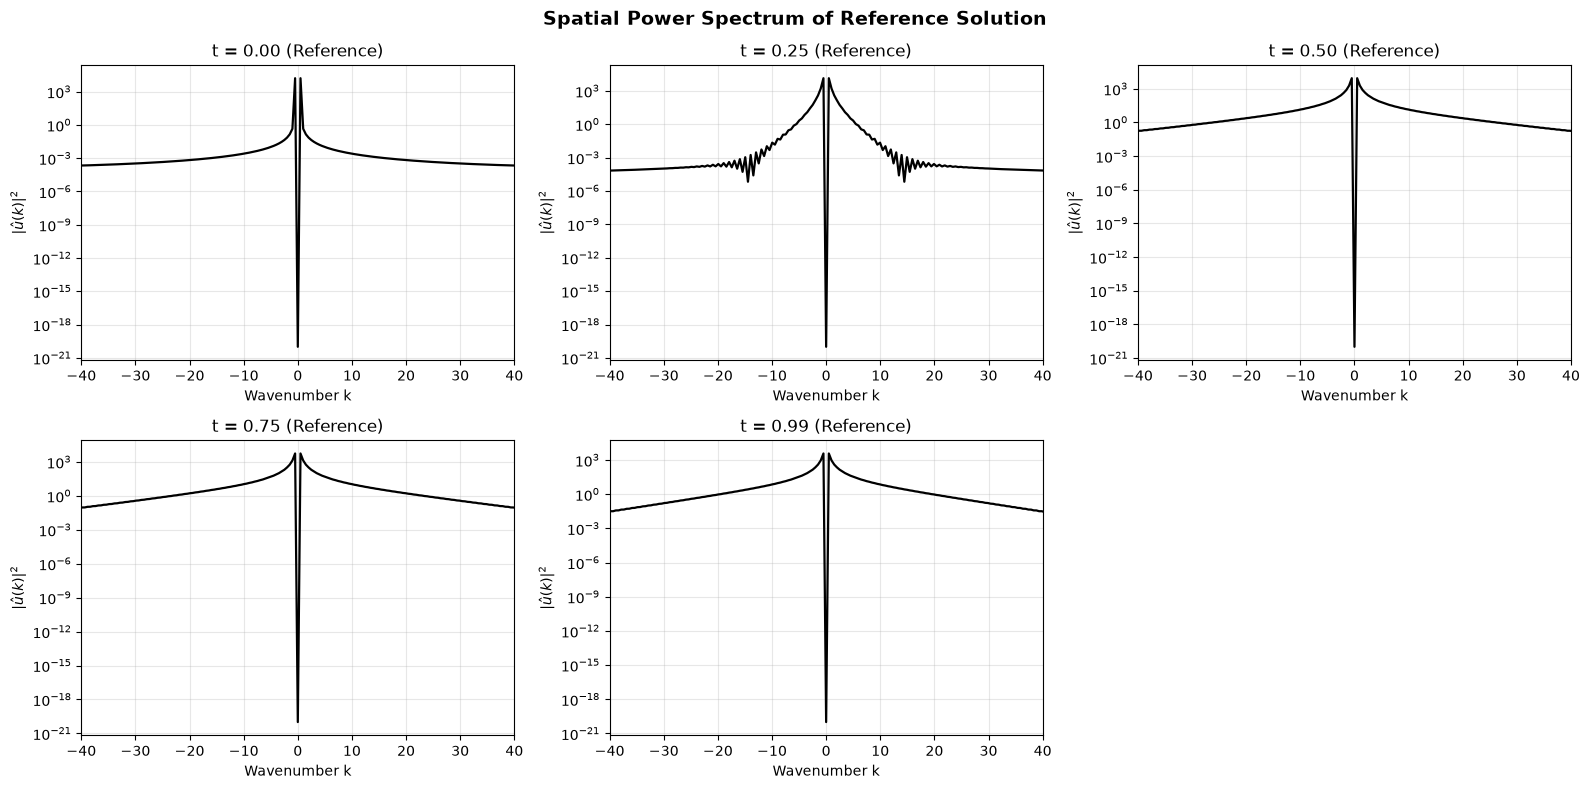


=== High-frequency content of Reference Solution ===
t = 0.00:  |k|>10 → 0.000003   |k|>20 → 0.000001
t = 0.25:  |k|>10 → 0.000002   |k|>20 → 0.000000
t = 0.50:  |k|>10 → 0.011628   |k|>20 → 0.002633
t = 0.75:  |k|>10 → 0.012577   |k|>20 → 0.002486
t = 0.99:  |k|>10 → 0.011028   |k|>20 → 0.001738


In [11]:
#spectral analysis of c-PINN data
Nx_eval = 256     
Nt_eval = 100

x_eval = torch.linspace(-1, 1, Nx_eval).view(-1, 1)
t_eval = torch.linspace(0, 1, Nt_eval).view(-1, 1)

X, T = torch.meshgrid(x_eval.squeeze(), t_eval.squeeze(), indexing='ij')
X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

model.eval()
with torch.no_grad():
    u_pred_flat = model(X_flat, T_flat).cpu().numpy().flatten()

u_pred = u_pred_flat.reshape(Nx_eval, Nt_eval)   

x_np = x_eval.numpy().flatten()
t_np = t_eval.numpy().flatten()
dx = x_np[1] - x_np[0]

print(f"Prediction shape: {u_pred.shape}  (Nx, Nt)")
print(f"x range: [{x_np[0]:.2f}, {x_np[-1]:.2f}]")

times_of_interest = [0.0, 0.25, 0.50, 0.75, 0.99]
time_indices = [np.argmin(np.abs(t_np - ti)) for ti in times_of_interest]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (ti, idx) in enumerate(zip(times_of_interest, time_indices)):
    u = u_pred[:, idx]                  

    u_hat = fftshift(fft(u))
    k = fftshift(fftfreq(Nx_eval, d=dx))

    power = np.abs(u_hat)**2
    power = np.maximum(power, 1e-20)

    ax = axes[i]
    ax.semilogy(k, power, 'r-', lw=1.6)
    ax.set_xlim(-40, 40)
    ax.set_xlabel("Wavenumber k")
    ax.set_ylabel(r"$|\hat{u}(k)|^2$")
    ax.set_title(f"t = {ti:.2f}  (c-PINN)")
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')
plt.suptitle("Spatial Power Spectrum of c-PINN Prediction", fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== High-frequency content of c-PINN prediction ===")
for ti, idx in zip(times_of_interest, time_indices):
    u = u_pred[:, idx]
    u_hat = fftshift(fft(u))
    k = fftshift(fftfreq(Nx_eval, d=dx))

    total = np.sum(np.abs(u_hat)**2)
    high  = np.sum(np.abs(u_hat[np.abs(k) > 10])**2) / total
    vhigh = np.sum(np.abs(u_hat[np.abs(k) > 20])**2) / total

    print(f"t = {ti:.2f}:  |k|>10 → {high:.4f}   |k|>20 → {vhigh:.4f}")



#spectral analysis for reference data
data = np.load("Burgers.npz")
t_ref_1d = data["t"].flatten()       
x_ref_1d = data["x"].flatten()    
exact = data["usol"]                

Nx_ref = len(x_ref_1d)
dx_ref = x_ref_1d[1] - x_ref_1d[0]

print(f"Reference shape: {exact.shape} (Nx, Nt)")
print(f"x range: [{x_ref_1d[0]:.2f}, {x_ref_1d[-1]:.2f}]")

times_of_interest = [0.0, 0.25, 0.50, 0.75, 0.99]
time_indices = [np.argmin(np.abs(t_ref_1d - ti)) for ti in times_of_interest]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (ti, idx) in enumerate(zip(times_of_interest, time_indices)):
    u_exact_slice = exact[:, idx]          

    u_hat_ref = fftshift(fft(u_exact_slice))
    k_ref = fftshift(fftfreq(Nx_ref, d=dx_ref))

    power_ref = np.abs(u_hat_ref)**2
    power_ref = np.maximum(power_ref, 1e-20)

    ax = axes[i]
    ax.semilogy(k_ref, power_ref, 'k-', lw=1.6)
    ax.set_xlim(-40, 40)
    ax.set_xlabel("Wavenumber k")
    ax.set_ylabel(r"$|\hat{u}(k)|^2$")
    ax.set_title(f"t = {ti:.2f} (Reference)")
    ax.grid(True, alpha=0.3)


axes[-1].axis('off')
plt.suptitle("Spatial Power Spectrum of Reference Solution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



print("\n=== High-frequency content of Reference Solution ===")
for ti, idx in zip(times_of_interest, time_indices):
    u_ref = exact[:, idx]
    u_hat_ref = fftshift(fft(u_ref))
    k_ref = fftshift(fftfreq(Nx_ref, d=dx_ref))

    total = np.sum(np.abs(u_hat_ref)**2)
    high  = np.sum(np.abs(u_hat_ref[np.abs(k_ref) > 10])**2) / total
    vhigh = np.sum(np.abs(u_hat_ref[np.abs(k_ref) > 20])**2) / total

    print(f"t = {ti:.2f}:  |k|>10 → {high:.6f}   |k|>20 → {vhigh:.6f}")